# Logistic Regression

## Introduction

Short recap:
What types of machine learning algorithms do you know? 
- supervised learning
- unsupervised learning

What types of supervised learning do you know?
- classification
- regression

Goal:
- understand the concept of logistic regression
- apply this method with the python built-in possibilites to penguins
- side effects: repetition of ML workflow and several pointers to upcoming encounters

## The sigmoid function  

We will meet this function more often in the following weeks:

$$p(f) = \frac{1}{1+e^{⁻f}}$$  

<font size="1"> Sidenote: For didactic reasons I have used f instead of x.</font> 

How does it look like graphically?

Text(0.5, 1.0, 'The sigmoid function p')

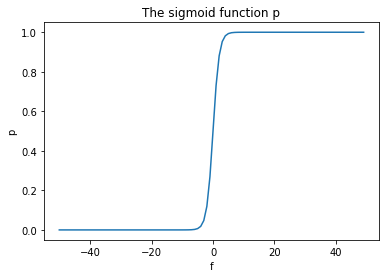

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

# create the sigmoid function
def my_function(f):
    '''Calculates p for given f'''
    # p = np.exp(-f)
    result = 1/(1+np.exp(-f))
    return result


f = np.arange(-50, 50, 1)  # creates numbers between -50 and 50 with a stepsize of 1
p = my_function(f)         # the 101 corresponding function results

plt.plot(f,p)
plt.xlabel('f')
plt.ylabel('p')
plt.title('The sigmoid function p')

What are the characteristics of this sigmoid function?  

How can we modify it?  

The only variable parameter in the sigmoid function is the _f_.
_f_ is called the *logit*. Here we let f be a linear function:

$$f(x) = b + w*x$$
_f_  is the response. (Here it is the input to the sigmoid function.)  
_x_  is the independent variable.   
_b_  is called intercept (where _f(x)_ intersects the y-axis).  
_w_  is called weight.  

Our sigmoid functions with f replaced looks like this:
$$p(x) = \frac{1}{1+e^{⁻(b + w*x)}}$$  

&rarr; To alter the simgoid function we can change _b_ and _w_. Let's try this:


In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

# create the sigmoid function
def sigmoid_function(f):
    '''Calculates p for given f'''
    p = 1/(1+np.exp(-f))
    return p

# create the logit function
def logit_function(x, b, w):
    '''Caluculates the border'''
    f = b + w*x
    return f

b = 0
w = 1

x = np.arange(-50, 50, 1)
f = logit_function(x, b, w)

p = sigmoid_function(f)

plt.plot(x,p) 
plt.suptitle('The sigmoid function p')
plt.title(f'for b={b} and w={w}')
plt.show()

Try out on your own how b and w change the result.  

result:
- $p(f(x))$ (the result of the sigmoid function) or in short $p(x)$ is mainly only 0 or 1 (about)
- b shifts the sigmoid function to the left and right
- Larger w's sharpen the sigmoid function.
- Real fractions of w smoothen the sigmoid function.
- Negative w's flip the sigmoid function.

## Conclusion

Assuming that b and w are known, we can input any x (a feature of our machine learning problem), and our sigmoid function tells us whether the observation belongs to category 0 or 1.  

The only requirement is to customize the model parameters b and w to our needs / input data so that it can be used to discrimitate/binarize/classify any numerical feature x. 

#### Two open questions:

##### 1. What about the p's which are not 0 or 1?   

##### Answer:  

$p(x)$ p can be interpreted as the probability that a certain x belongs to the group of 1's (and vice versa).  
&nbsp;&nbsp;&nbsp;&nbsp;=> use a threshold, e.g. 0.5 for discrimination  

##### 2. How can we know the best suited b and w?

##### Answer:

This is what logistic regression does for us. The process is called fitting or training.  
&nbsp;&nbsp;&nbsp;&nbsp;For the training, the algorithm (e.g. gradient descent) minimizes a so-called loss function (also named error/cost/objective function).  
&nbsp;&nbsp;&nbsp;&nbsp;This minimum ensures that the best parameters (b, w) were found.

#####  For the particularly interested:

For logistic regression the **log loss function** LLF (also referred to as **binary cross entropy**) is used:  
$LLF = -\frac{1}{n}\sum_{i=0}^n\Bigg[ \Bigg(y_i \ln(p(x_i))\Bigg) + \Bigg((1-y_i) \ln(1-p(x_i))\Bigg)\Bigg]\quad$  

with $n$ being the number of observations,  
$y_i$ being the real observations (0 or 1)  
and $p(x_i)$ being the predictions, between 0 and 1  


| $y_i$ (real value) | $p(x_i)$ (prediction) | val in [] |
| :- | :- | :- |
| 0 | $ \sim 0$ | $ \sim 0$
| 0 | $\neq 0$ | large
| 1 | $ \sim 1$ | $ \sim 0$ 
| 1 | $\neq 1$ | large

&rarr; The further the prediction is from the real value, the larger the LLF  
_vice versa_: **The smaller the loss, the better the prediction.**  



REMEMBER the term "loss function" (= objective function, cost function). We will meet it regularly in the future.
You can find a [chapter](https://spiced.space/poisson-ivy/ds-course/chapters/project_titanic/log_loss/README.html) about log loss in the course material.

## Let's carry out an example on our ML workflow now

### 1. Define (business) goal

Train a model that is as accurate as possible to predict if a penguin belongs to the Gentoo or the Adelie `species` using only the feature `body mass`

### 2. Get Data 

- Read in data set from `seaborn` (Data set is part of the sns library.)
- Get rid of the third class (Chinstrap) as we want a binary classification

In [2]:
df = sns.load_dataset('penguins')
df.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


In [3]:
df.shape

(344, 7)

In [4]:
df['species'].value_counts()  # How many values per species

Adelie       152
Gentoo       124
Chinstrap     68
Name: species, dtype: int64

Let's for simplicity exclude the Chinstraps for now

In [5]:
df = df[df['species'] != 'Chinstrap']

In [6]:
df = df.dropna()  # remove na's

In [7]:
df.shape

(265, 7)

In [8]:
df['species'].value_counts()

Adelie    146
Gentoo    119
Name: species, dtype: int64

### 3. Train-test split 

Separate X and y

Terminology:
- The variables (X) with which we want to predict something are called &emsp;features, inputs, predictors, or independent variables.  
- The variables (y) which we want to predict are called &emsp;outputs, responses, or dependent variables.

In [9]:
y = df['species']
y.shape

(265,)

In [10]:
type(y) # <- is a Series

pandas.core.series.Series

In [11]:
y

0      Adelie
1      Adelie
2      Adelie
4      Adelie
5      Adelie
        ...  
338    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 265, dtype: object

In [12]:
X = df[['body_mass_g']] # <- select feature(s) with double [[]] brackets even it's only one feature!!!

In [13]:
type(X) # <- is a dataframe

pandas.core.frame.DataFrame

In [14]:
X

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
4,3450.0
5,3650.0
...,...
338,4925.0
340,4850.0
341,5750.0
342,5200.0


Train-test split

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

What about the _random_state_ parameter?  
It tells the splitter to split the data in a certain, distinct way. (In fact this is no _random_ splitting anymore.) Usually you don't set this parameter so that the splitting is really random. But for debugging/educational purposes, this possibility is nice because you always have the same splitting. The _42_ could also be any other integer. 

In [19]:
X_train.shape, X_test.shape

((212, 1), (53, 1))

In [20]:
y_train.shape, y_test.shape

((212,), (53,))

|  | feature(s)<br>X | responses<br>y
| - | - | - 
| train<br>(e.g. 80%) | X_train | y_train 
| test<br>(e.g. 20%) | X_test | y_test 

### 4. Explore the data

If we separated X and y before test-train-split but want to explore the data **with** our labels, we can concatenate X and y of the test data again:

In [23]:
df_train = pd.concat([X_train, y_train], axis = 1)

In [24]:
df_train.head()

,body_mass_g,species
247,5650.0,Gentoo
308,4875.0,Gentoo
23,3950.0,Adelie
96,3700.0,Adelie
257,5250.0,Gentoo


use seaborn's categorical plot

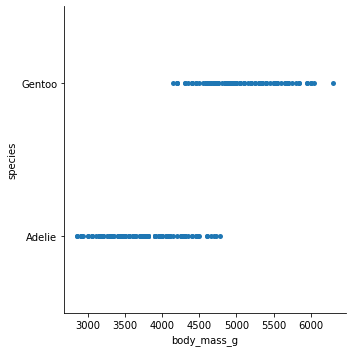

In [26]:
sns.catplot(data = df_train, x = 'body_mass_g', y = 'species', jitter=False)  

### 5. Feature Engineering 

Skipped for now: topic for tomorrow. 
- Feature engineering is very important for logisitic regression LR, because:
    - LR doesn't take missing values
    - LR can't work with categorical features. (Though the labels can be strings.)  
    - LR likes to have the numerical data more or less in in the same scale range. 


'Luckily' our goal was defined using only a numerical variable (the penguin mass).

### 6. Train Model

* Classify a penguin as 'Adelie' (0) or 'Gentoo' (1) 
* Use only Body Mass as X
* We would like to find the coefficients (b, w) of the logistic function that result in the most accurate model (smallest possible log loss)

**Logistic regression**

In [27]:
from sklearn.linear_model import LogisticRegression

In [29]:
m = LogisticRegression()

In [30]:
m.fit(X_train, y_train)

LogisticRegression()

Take a look at the coefficients (just out of curiosity, not necessary)

In [35]:
w = m.coef_

In [32]:
b = m.intercept_

In [33]:
f' w: {w[0][0]} and b: {b[0]}'

' w: 0.00636809526155041 and b: -28.186982294148613'

#### Bonus: check output Sigmoid Function

In [36]:
# Create the sigmoid function
def sigmoid_function(x, b, w):
    '''Calculates the y value for given x, b and w'''
    y = 1/(1+np.exp(-(b + w*x)))
    return y

def logit_function(x, b, w):
    '''Caluculates the border'''
    y = b + w*x
    return y

In [37]:
df['Sigmoid'] = sigmoid_function(X, b, w)

In [40]:
df.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Sigmoid
113,Adelie,Biscoe,42.2,19.5,197.0,4275.0,Male,0.276203
292,Gentoo,Biscoe,48.2,15.6,221.0,5100.0,Male,0.986484
287,Gentoo,Biscoe,49.5,16.2,229.0,5800.0,Male,0.999841
67,Adelie,Biscoe,41.1,19.1,188.0,4100.0,Male,0.111274
71,Adelie,Torgersen,39.7,18.4,190.0,3900.0,Male,0.033849


In [41]:
df['Predicted Species'] = round(df['Sigmoid'],0).astype(int)

In [42]:
df.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Sigmoid,Predicted Species
37,Adelie,Dream,42.2,18.5,180.0,3550.0,Female,0.003757,0
277,Gentoo,Biscoe,45.5,15.0,220.0,5000.0,Male,0.974753,1
148,Adelie,Dream,36.0,17.8,195.0,3450.0,Female,0.001991,0
97,Adelie,Dream,40.3,18.5,196.0,4350.0,Male,0.380891,0
99,Adelie,Dream,43.2,18.5,192.0,4100.0,Male,0.111274,0


(-0.1, 1.1)

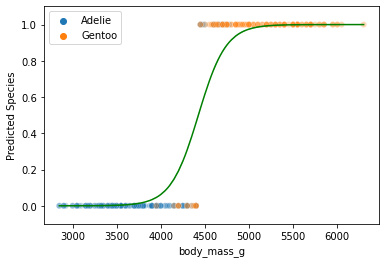

In [43]:
sns.scatterplot(x = df['body_mass_g'], y = df["Predicted Species"], hue = df["species"], alpha = 0.3)

sns.lineplot(x = df['body_mass_g'], y = df["Sigmoid"], color = "green")

plt.ylim((-0.1, 1.1))

### 7. Optimize

Not for now.

### 8. Evaluate model

Let's use our model `m` to predict the **test data** which it has never seen.

In [44]:
m.predict(X_test)

array(['Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie'], dtype=object)

In [45]:
# How large are the probabilities that the test penguins belong to one or the other species?
prob = m.predict_proba(X_test)

In [46]:
# Let's investigate the first (10) samples

prob[0:10]

array([[9.86636615e-03, 9.90133634e-01],
       [9.97264356e-01, 2.73564436e-03],
       [9.99816862e-01, 1.83137647e-04],
       [9.54043151e-01, 4.59568490e-02],
       [5.41743394e-01, 4.58256606e-01],
       [9.92920411e-01, 7.07958946e-03],
       [1.93931977e-01, 8.06068023e-01],
       [6.90866347e-01, 3.09133653e-01],
       [9.54043151e-01, 4.59568490e-02],
       [9.97264356e-01, 2.73564436e-03]])

In [47]:
prob[:,0] + prob[:,1] # sum must be 1 because each penguin belongs to either Adelie or Gentoo.

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1.])

In [48]:
evaluate_testdata = pd.DataFrame()  # create empty df
evaluate_testdata['real species'] = y_test  # the real, correct labels
evaluate_testdata['prediction'] = m.predict(X_test)  # the predicted labels (automatically transformed to strings)
evaluate_testdata['prob for Adelie'] = prob[:,0]  # the probability for Adelie
evaluate_testdata['prob for Gentoo'] = prob[:,1]  # the probability for Gentoo

In [49]:
evaluate_testdata

,real species,prediction,prob for Adelie,prob for Gentoo
254,Gentoo,Gentoo,0.009866,0.990134
121,Adelie,Adelie,0.997264,0.002736
102,Adelie,Adelie,0.999817,0.000183
29,Adelie,Adelie,0.954043,0.045957
14,Adelie,Adelie,0.541743,0.458257
145,Adelie,Adelie,0.992920,0.007080
332,Gentoo,Gentoo,0.193932,0.806068
51,Adelie,Adelie,0.690866,0.309134
260,Gentoo,Adelie,0.954043,0.045957
131,Adelie,Adelie,0.997264,0.002736


#### How good is our model in numbers?

The manual way

In [51]:
number_of_correct_predictions = evaluate_testdata[evaluate_testdata['real species'] ==\
                                                evaluate_testdata['prediction']].shape         
number_of_correct_predictions, evaluate_testdata.shape

((49, 4), (53, 4))

In [52]:
number_of_correct_predictions[0] / evaluate_testdata.shape[0]

0.9245283018867925

The comfortable way

In [54]:
# calculate the accuracy (how many percent where predicted correctly)

m.score(X_test, y_test)
f'{100*round(m.score(X_test, y_test),2)} % of the penguins were predicted correctly.'


'92.0 % of the penguins were predicted correctly.'

You will learn more about evaluation on Wednesday.

### 9. Predict

We can now use our model m to predict whether a certain penguin is an Adelie or a Gentoo just by the body mass:

In [60]:
m.predict([[4500]]) # should actually be formatted like a pandas dataframe => warning, but can be ignored for now

/home/thomas/.local/lib/python3.8/site-packages/sklearn/base.py:445: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Gentoo'], dtype=object)

## Extension to more than one dimension

The concept of logistic regression can also be used for  
- multivariate problems, i.e. there is more than one feature (= independent variable):  
&emsp;not only $x$ as shown above but $x_1, x_2, x_3$, ...
- multi-class (== multi-nomial) problems, i.e. there can be more than two response possibilities (not just 0 and 1)   

bivariate example with 3 classes:

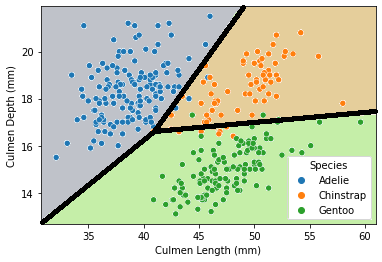

BTW: sklearn is used in the same way as shown above even for multivariate and/or multiclass problems (same syntax).

## Summary

- We investigated the sigmoid function
- which can be adapted to create linear borders between (two) classes (=> logistic regression).
- We saw a loss function and know that ML algorithms work by minimizing a loss function.
- We followed our machine learning recipe to create a logress model for penguin discrimination,
- and investigated the goodness of the model by using previously separated test data.
- The model can now be used to predict completely new penguins.
- We learned that logress can also be used for multivarate and multiclass problems.
- We met several pointers to future encounters (feature engineering, gradient descent, eval. classifiers, cross validation, optimization, ...)

## Additional readings

https://towardsdatascience.com/understanding-sigmoid-logistic-softmax-functions-and-cross-entropy-loss-log-loss-dbbbe0a17efb  

https://towardsdatascience.com/intuition-behind-log-loss-score-4e0c9979680a